In [1]:
import numpy as np
import random
import math

## Creating Generator and Parity Matrix for BCH[15,5,7]

In [2]:
'''generator and parity matrix for BCH [15,5,7]'''

g = np.polynomial.Polynomial((1,1,1,0,1,1,0,0,1,0,1))
print("Creating generator matrix using the g(x) = ")
print(g)
g_vec = [1,1,1,0,1,1,0,0,1,0,1]
G = np.zeros((5,15), int)
for i in range(5):
    G[i,i:i+11] = g_vec
print("\nGenerator matrix -> G =\n")
print(G)

# row reduced form of G, to get G = [I|P]
for i in range(1,5):
    j = i-1
    while j >-1:
        if G[j,i] == 1:
            G[j,:] = (G[j,:] + G[i,:])%2
        j -= 1

print("\nRow Reduced form of G ([I|P]) =\n")
print(G)    

" parity matrix for G"
P = G[:,5:]
H_BCH = np.concat((P.T,np.eye(10, dtype = int)),axis=1)
print("\n Parity Matrix\n")
print(H_BCH)
S = G@H_BCH.T %2
print("\n verifying if G*H^T = 0 mod(2):",np.array_equal(S, np.zeros((5,10))))

Creating generator matrix using the g(x) = 
1.0 + 1.0·x + 1.0·x² + 0.0·x³ + 1.0·x⁴ + 1.0·x⁵ + 0.0·x⁶ + 0.0·x⁷ +
1.0·x⁸ + 0.0·x⁹ + 1.0·x¹⁰

Generator matrix -> G =

[[1 1 1 0 1 1 0 0 1 0 1 0 0 0 0]
 [0 1 1 1 0 1 1 0 0 1 0 1 0 0 0]
 [0 0 1 1 1 0 1 1 0 0 1 0 1 0 0]
 [0 0 0 1 1 1 0 1 1 0 0 1 0 1 0]
 [0 0 0 0 1 1 1 0 1 1 0 0 1 0 1]]

Row Reduced form of G ([I|P]) =

[[1 0 0 0 0 1 1 1 0 1 1 0 0 1 0]
 [0 1 0 0 0 0 1 1 1 0 1 1 0 0 1]
 [0 0 1 0 0 1 1 0 1 0 1 1 1 1 0]
 [0 0 0 1 0 0 1 1 0 1 0 1 1 1 1]
 [0 0 0 0 1 1 1 0 1 1 0 0 1 0 1]]

 Parity Matrix

[[1 0 1 0 1 1 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 1 0 1 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 1 1 0 0 0 0 1 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0 0 1 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 1 1 0 0 0 0 0 0 0 0 0 1]]

 verifying if G*H^T = 0 mod(2): True


In [3]:
" Getting all the codewords for G"
import itertools
it = itertools.product([0,1],repeat = 5)
Codes_BCH = []
for i in it:
    Codes_BCH.append((np.array(i) @ G)%2)

In [4]:
sigma = 0.1
Noise = np.random.uniform(0,sigma,size = H_BCH.shape[1])  # Using AWGN

code = Codes_BCH[np.random.randint(0,31)]
print(code)

signal = 1 - 2 * code                                 # BPSK 
print(signal)

LLR = [float(2*i/sigma**2) for i in signal + Noise]  # LLR claculation based on AWGN and BPSK
print(LLR)
# 2 more matrix for communication between VN to CN and CN to VN
m_v_to_c, m_c_to_v = np.zeros(H_BCH.shape), np.zeros(H_BCH.shape)

[0 1 0 1 0 0 0 0 1 1 1 0 1 1 0]
[ 1 -1  1 -1  1  1  1  1 -1 -1 -1  1 -1 -1  1]
[204.58139867446403, -189.98669619843707, 213.96357341668843, -188.05612642088104, 212.09836533914128, 201.19739834866573, 214.11610035626296, 211.0150022903158, -195.78424757852252, -191.1789744877036, -198.9950732167874, 204.3150924441664, -197.29013314586834, -182.8603963813091, 218.14153058182302]


# Defining Min-Sum Decoder, which takes parity matrix H, LLR, max_ (limiting value, helpful for hardware limitation) and number of maximum iterations

In [5]:
def Min_sum_decoder(H, LLR, max_, iterations):
    
    """ Note that we are using H[j,i] == 1 condition to ensure that we are only working with the connected edges
        It will be used in both communications, VN to CN and CN to VN"""
    llr_max = max(LLR)
    n, m = H.shape[0], H.shape[1]
    m_v_to_c, m_c_to_v = np.zeros(H.shape), np.zeros(H.shape)
    final_LLR = list(np.zeros(len(LLR)))
    
    for itr in range(iterations):                             # user defined maximum number of iterations
        stop = False                                          # for early stopping
        for i in range(m):                                    # main loop to update ith VN
            total = LLR[i] + np.sum(m_c_to_v[:,i])            # saving total sum value to be used multiple times
    
            ''' Communication from ith VN to jth CN'''
            for j in range(n):                                # loop to check for all CNs
                if H[j,i] == 1:                               # H[j,i] == 1 ensure that we are only working with the connected edges
                    m_v_to_c[j,i] = total - m_c_to_v[j,i]     # for BP or Min-Sum, remove the message info from that exact ith node
                    
            ''' Communication from jth CN to ith VN'''
            for j in range(n):                                # each CN will send message to its connecting VNs    
                
                if np.sum(H[j,:]) == 1 and H[j,i] == 1:       # condition for degree 1 CN and has an edge connecting to ith VN
                    m_c_to_v[j,i] = max(max_, llr_max*1.1)      # setting max LLR for 0 bit, can also enforce code bit to be 0
                    
                elif np.sum(H[j,:]) > 1:                      # Condition for higher degree CNs
                    t = float('inf')                          # varibale to store min absolute value
                    s = 1                                     # varibale to store product of signs
                    for k in range(m):                        # loop to get info messages from all VNs for jth CN
                        if H[j,k] == 1 and k != i:            # ignoring the message from ith VN (the one which we need to update)
                            t = min(t, abs(m_v_to_c[j,k]))    # getting min absolute value
                            s *= int(np.sign(m_v_to_c[j,k]))  # getting product of signs
                            
                    if H[j,i] == 1:                           # sending the message from jth CN to ith VN 
                        m_c_to_v[j,i] = t*s                   # sending message using min-sum
                else:                                         # else there are no edges and we can skip
                    continue
    
            ''' uptading the final ith VN LLR value based on all the info from original ith VN LLR and messages from all connecting CNs'''
            
            final_LLR[i] = int(min(abs((LLR[i]+ np.sum(m_c_to_v[:,i]))), max(max_,llr_max)) * np.sign(int((LLR[i]+ np.sum(m_c_to_v[:,i]))))) 
            # Converting final LLR to bitsting (with a condition where final LLR = 0, we place 2, that is invalid code)
            code = []
            for i in final_LLR:
                if i > 0:
                    code.append(0)
                elif i < 0:
                    code.append(1)
                else:
                    code.append(np.random.randint(0,2))
                    
            if all(np.array(code) < 2) and all((H @ code)%2 == np.zeros(n)): # if  code is valid and H.code mod(2) is 0, we found a valid code
                stop = True                                                  # early stopping
                
        if stop:
            #print('Done in ',itr, 'iterations')
            break
            
    #print(final_LLR)
    #print(code)
    return final_LLR, code, itr

In [6]:
def checker(H, strength = 0.01, Codes = Codes_BCH, times = 100):
    max_ = 255
    scale = 10
    count = 0
    sigma = strength 
    power_signal, power_noise = np.zeros((times)),np.zeros((times))
    for i in range(times):
        Noise = np.random.uniform(0,sigma,size = H.shape[1])
        code = Codes[np.random.randint(len(Codes))]
        signal = 1 - 2 * code
        power_signal[i] = np.mean(signal ** 2)
        power_noise[i] = np.mean(Noise ** 2)
        LLR = [float(2*i/sigma**2) for i in signal + Noise]
        final_LLR, predicted_code, itr = Min_sum_decoder(H, LLR, max_, iterations = 25)
        for j in range(len(code)):
            if code[j] == predicted_code[j]:
                count += 1
    P_s, P_n = np.mean(power_signal), np.mean(power_noise)
    snr_linear = P_s/P_n
    snr_db = 10 * np.log10(snr_linear)
    return count/(len(code)*times), snr_linear, snr_db

In [7]:
Strength = [0.05,0.1, 0.2,0.5,0.75,0.8,0.9,1,1.1,1.2,1.5,1.75,1.8,2,2.1,2.2,2.5]
C = []
S_linear = []
S_db = []
for s in Strength:
    a,b,c = checker(H_BCH, strength =s)
    C.append(a)
    S_linear.append(b)
    S_db.append(c)
    print("Done for Strength:",s)

Done for Strength: 0.05
Done for Strength: 0.1
Done for Strength: 0.2
Done for Strength: 0.5
Done for Strength: 0.75
Done for Strength: 0.8
Done for Strength: 0.9
Done for Strength: 1
Done for Strength: 1.1
Done for Strength: 1.2
Done for Strength: 1.5
Done for Strength: 1.75
Done for Strength: 1.8
Done for Strength: 2
Done for Strength: 2.1
Done for Strength: 2.2
Done for Strength: 2.5


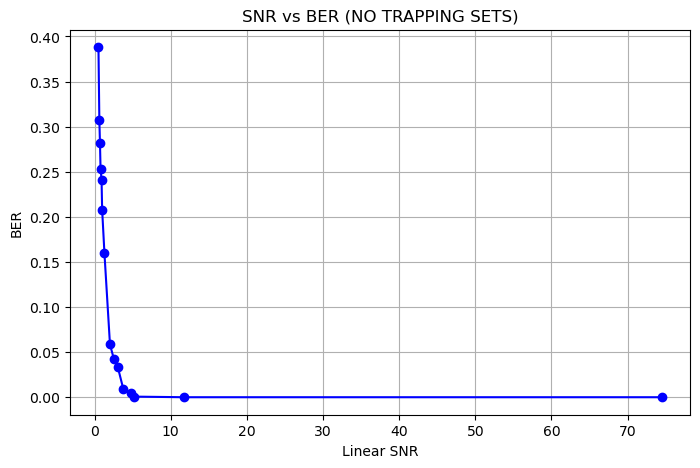

In [8]:
import matplotlib.pyplot as plt
import numpy as np

x = S_linear[2:]
y = list(1-np.array(C[2:]))

plt.figure(figsize=(8, 5))  

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.title('SNR vs BER (NO TRAPPING SETS)')
plt.xlabel('Linear SNR')
plt.ylabel('BER')
plt.grid(True)    
plt.show()

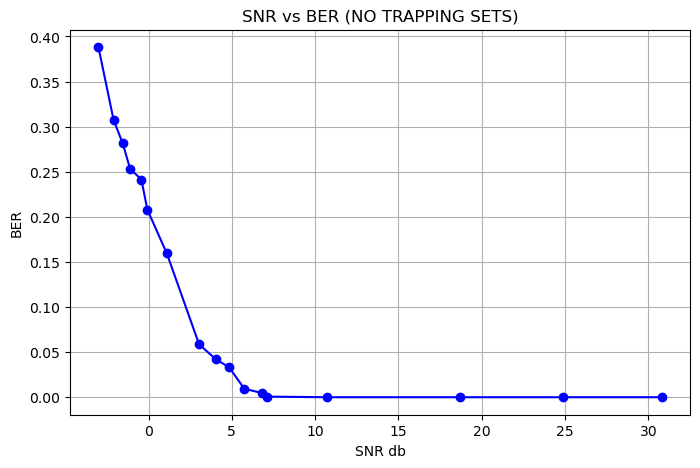

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x = S_db
y = list(1-np.array(C))

plt.figure(figsize=(8, 5))  

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.title('SNR vs BER (NO TRAPPING SETS)')
plt.xlabel('SNR db')
plt.ylabel('BER')
plt.grid(True)    
plt.show()

## Random H matrix with trapping sets

In [10]:
H = np.array([[ 1, 1, 0, 0, 1, 0, 1, 0],
              [ 0, 1, 1, 0, 0, 1, 0, 1],
              [ 0, 0, 1, 1, 0, 0, 1, 0],
              [ 1, 0, 0, 1, 0, 0, 0, 1],
              [ 1, 0, 0, 0, 1, 0, 0, 0],
              [ 0, 0, 0, 1, 0, 1, 0, 0]])
H

array([[1, 1, 0, 0, 1, 0, 1, 0],
       [0, 1, 1, 0, 0, 1, 0, 1],
       [0, 0, 1, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 0, 0, 1],
       [1, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 0]])

In [11]:
def rref_H_and_G_(H):
    H = H.copy()
    n,m = H.shape
    i = 0
    pivot_cols = []

    for j in range(m):
        pivot = None
        for k in range(i, n):
            if H[k, j] == 1:
                pivot = k
                break

        if pivot is None:
            continue
        
        if pivot != i:
            H[[i, pivot]] = H[[pivot, i]]

        for r in range(n):
            if H[r, j] == 1 and r != i:
                H[r] ^= H[i]

        pivot_cols.append(j)
        i += 1

        if i == n:
            break
            
    P_cols  = list(i for i in range(m) if i not in pivot_cols)
    P = H[:,P_cols]
    G_ = np.concat((P.T, np.eye(P.shape[1], dtype=np.uint8)), axis = 1)
    rearranged = np.concat((pivot_cols, P_cols))
    inverse_arrangment = np.argsort(rearranged)
    G = G_[:, inverse_arrangment]
    return H, G
            
H_, G = rref_H_and_G_(H)
print(H_)
print(G)
print((H_ @ G.T)%2)

[[1 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 0]
 [0 0 1 0 0 1 1 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]]
[[1 0 1 1 1 1 0 0]
 [0 1 1 0 0 0 1 0]]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


In [12]:
it = itertools.product([0,1], repeat = G.shape[0])
Codes_ = np.array([(i @ G) % 2 for i in it])

Strength = [0.05,0.1, 0.2,0.5,0.75,0.8,0.9,1,1.1,1.2,1.5,1.75,1.8,2,2.1,2.2,2.5]

C = []
S_linear = []
S_db = []

for s in Strength:
    a,b,c = checker(H_, strength =s, Codes = Codes_)
    C.append(a)
    S_linear.append(b)
    S_db.append(c)
    print("Done for Strength:",s)

Done for Strength: 0.05
Done for Strength: 0.1
Done for Strength: 0.2
Done for Strength: 0.5
Done for Strength: 0.75
Done for Strength: 0.8
Done for Strength: 0.9
Done for Strength: 1
Done for Strength: 1.1
Done for Strength: 1.2
Done for Strength: 1.5
Done for Strength: 1.75
Done for Strength: 1.8
Done for Strength: 2
Done for Strength: 2.1
Done for Strength: 2.2
Done for Strength: 2.5


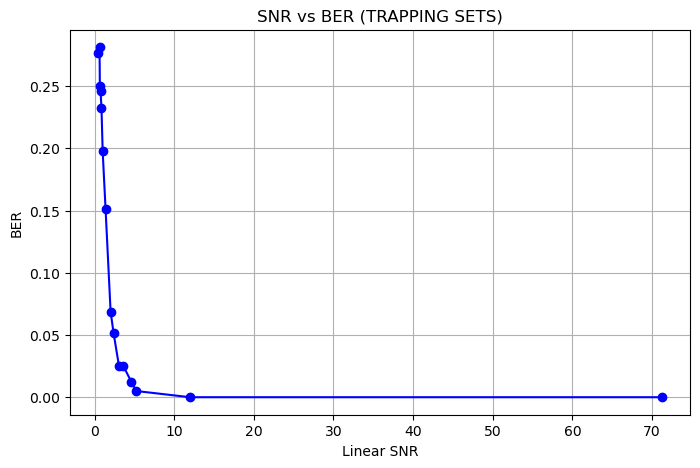

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = S_linear[2:]
y = list(1-np.array(C[2:]))

plt.figure(figsize=(8, 5))  

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.title('SNR vs BER (TRAPPING SETS)')
plt.xlabel('Linear SNR')
plt.ylabel('BER')
plt.grid(True)    
plt.show()

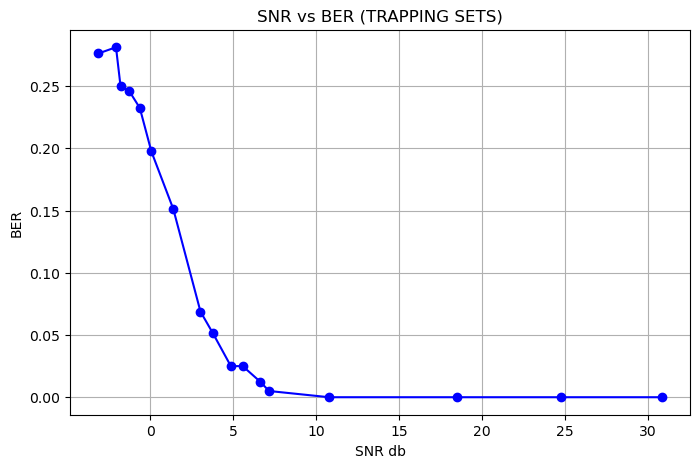

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = S_db
y = list(1-np.array(C))

plt.figure(figsize=(8, 5))  

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.title('SNR vs BER (TRAPPING SETS)')
plt.xlabel('SNR db')
plt.ylabel('BER')
plt.grid(True)    
plt.show()